In [2]:
#imports
import os
from pathlib import Path
from PIL import Image
import cv2
import matplotlib.pyplot as plt

print("Imported Successfully")

Imported Successfully


In [21]:
char_set = "@%#*+=-:."  # heavy → light
#char_set = "$@B%8&WM#*oahkbdpqwmZO0QLCJUYXzcvunxrjft/\|()1[]?-_+~<>i!lI;:,"
def image_to_ascii(image, width=120):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    aspect_ratio = h / w
    height = int(width * aspect_ratio * 0.55)

    resized = cv2.resize(gray, (width, height))

    ascii_img = []
    for row in resized:
        line = ""
        for pixel in row:
            idx = int(pixel / 255 * (len(char_set) - 1))
            line += char_set[idx]
        ascii_img.append(line)

    return ascii_img



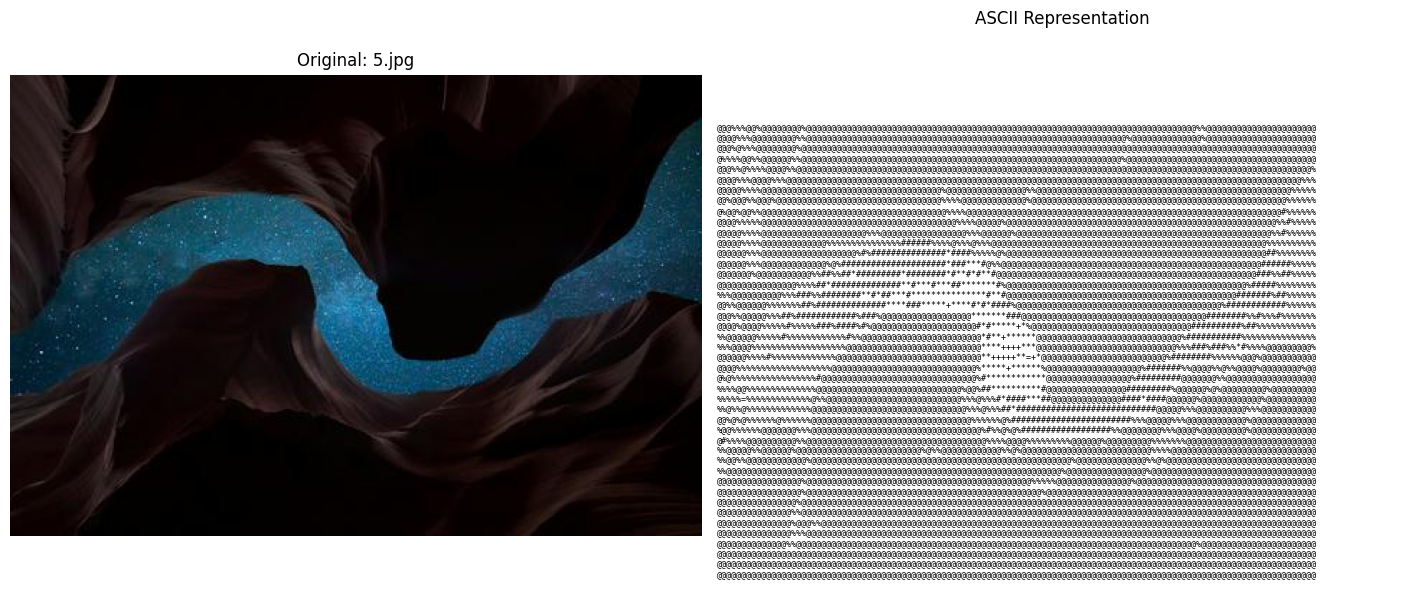

In [31]:
#Testing
#Load images from folder in bulk

imgfolder = "resized_images"
images = []

for filename in os.listdir(imgfolder):
    path = os.path.join(imgfolder, filename)
    img = cv2.imread(path)
    images.append((filename, img))

image_no = 5

name,img = images[image_no-1]
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
ascii_img = image_to_ascii(img_rgb)

plt.figure(figsize=(15,6))

# ORIGINAL IMAGE
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title(f"Original: {name}")
plt.axis("off")

# ASCII IMAGE
plt.subplot(1,2,2)
plt.title("ASCII Representation")
plt.axis("off")

plt.text(
    0, 0,
    "\n".join(ascii_img),
    fontfamily="monospace",
    fontsize=6
)

plt.tight_layout()
plt.show()